In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
 
sns.set(color_codes=True)
plt.rcParams['figure.figsize'] = (10, 5)

In [ ]:
df = pd.read_csv('data\\XWines_Slim_150K_ratings.csv')
df['Date'] = pd.to_datetime(df['Date'])
 
# ═════════════════════════════════════════════════════════════════════════════
# 1. TABELA ZBIORCZA — kluczowe metryki zbioru
# ═════════════════════════════════════════════════════════════════════════════
n_users  = df['UserID'].nunique()
n_wines  = df['WineID'].nunique()
n_ratings = len(df)
sparsity = n_ratings / (n_users * n_wines)
date_min = df['Date'].min().strftime('%Y-%m-%d')
date_max = df['Date'].max().strftime('%Y-%m-%d')
avg_rating = df['Rating'].mean()
median_rating = df['Rating'].median()
skewness = df['Rating'].skew()
kurtosis = df['Rating'].kurtosis()
mode_rating = df['Rating'].mode()[0]

 
print("=" * 55)
print("TABELA ZBIORCZA (skopiuj do LaTeX)")
print("=" * 55)
print(f"Liczba ocen:               {n_ratings:,}")
print(f"Liczba użytkowników:       {n_users:,}")
print(f"Liczba win:                {n_wines:,}")
print(f"Sparsity macierzy:         {sparsity:.4%}")
print(f"Zakres dat:                {date_min} – {date_max}")
print(f"Średnia ocena:             {avg_rating:.4f}")
print(f"Mediana oceny:             {median_rating:.1f}")
print(f"Skośność (skewness):       {skewness:.4f}")
print(f"Kurtoza:                   {kurtosis:.4f}")
print(f"Dominanta oceny:           {mode_rating}")

TABELA ZBIORCZA (skopiuj do LaTeX)
Liczba ocen:               150,000
Liczba użytkowników:       10,561
Liczba win:                1,007
Sparsity macierzy:         1.4104%
Zakres dat:                2012-04-19 – 2021-12-31
Średnia ocena:             3.8200
Mediana oceny:             4.0
Skośność (skewness):       -0.5175
Kurtoza:                   1.0728
Dominanta oceny:           4.0


C:\Users\Filip\AppData\Local\Temp\ipykernel_9752\4138456073.py:1: DtypeWarning: Columns (0: Vintage) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data\\XWines_Slim_150K_ratings.csv')


: 

In [4]:
# ═════════════════════════════════════════════════════════════════════════════
# 2. ROZKŁAD OCEN — tabela procentowa + skewness
# ═════════════════════════════════════════════════════════════════════════════
print("\n--- Rozkład procentowy ocen ---")
rating_dist = df['Rating'].value_counts(normalize=True).sort_index() * 100
for r, pct in rating_dist.items():
    print(f"  Ocena {r}: {pct:.2f}%")


--- Rozkład procentowy ocen ---
  Ocena 1.0: 0.32%
  Ocena 1.5: 0.23%
  Ocena 2.0: 1.29%
  Ocena 2.5: 2.60%
  Ocena 3.0: 12.83%
  Ocena 3.5: 24.35%
  Ocena 4.0: 36.02%
  Ocena 4.5: 14.74%
  Ocena 5.0: 7.64%


In [5]:
# ═════════════════════════════════════════════════════════════════════════════
# 3. COLD START — użytkownicy i wina
# ═════════════════════════════════════════════════════════════════════════════
user_counts = df.groupby('UserID')['Rating'].count()
wine_counts = df.groupby('WineID')['Rating'].count()
 
cold_users_3  = (user_counts < 3).sum()
cold_users_5  = (user_counts < 5).sum()
cold_users_10 = (user_counts < 10).sum()
cold_wines_5  = (wine_counts < 5).sum()
cold_wines_10 = (wine_counts < 10).sum()
 
print("\n--- Cold Start (użytkownicy) ---")
print(f"  Użytkownicy z < 3  ocenami: {cold_users_3:,}  ({cold_users_3/n_users*100:.1f}%)")
print(f"  Użytkownicy z < 5  ocenami: {cold_users_5:,}  ({cold_users_5/n_users*100:.1f}%)")
print(f"  Użytkownicy z < 10 ocenami: {cold_users_10:,} ({cold_users_10/n_users*100:.1f}%)")
print("\n--- Cold Start (wina) ---")
print(f"  Wina z < 5  ocenami: {cold_wines_5:,}  ({cold_wines_5/n_wines*100:.1f}%)")
print(f"  Wina z < 10 ocenami: {cold_wines_10:,} ({cold_wines_10/n_wines*100:.1f}%)")
 


--- Cold Start (użytkownicy) ---
  Użytkownicy z < 3  ocenami: 257  (2.4%)
  Użytkownicy z < 5  ocenami: 307  (2.9%)
  Użytkownicy z < 10 ocenami: 2,150 (20.4%)

--- Cold Start (wina) ---
  Wina z < 5  ocenami: 65  (6.5%)
  Wina z < 10 ocenami: 156 (15.5%)


In [6]:
# ═════════════════════════════════════════════════════════════════════════════
# 4. TOP 10 NAJCZĘŚCIEJ OCENIANYCH WIN
# ═════════════════════════════════════════════════════════════════════════════
top10_wines = wine_counts.sort_values(ascending=False).head(10).reset_index()
top10_wines.columns = ['WineID', 'Liczba ocen']
top10_wines['Średnia ocena'] = top10_wines['WineID'].map(
    df.groupby('WineID')['Rating'].mean().round(2)
)
print("\n--- Top 10 win wg liczby ocen ---")
print(top10_wines.to_string(index=False))


--- Top 10 win wg liczby ocen ---
 WineID  Liczba ocen  Średnia ocena
 167418         1540           3.88
 167419         1390           3.51
 155308         1181           4.34
 179012         1160           4.46
 193478         1131           4.22
 162497         1118           4.66
 111395         1084           4.69
 167429         1010           4.21
 167445          973           3.83
 135860          960           4.16


In [7]:
# ═════════════════════════════════════════════════════════════════════════════
# 5. KORELACJA: popularność wina vs średnia ocena
# ═════════════════════════════════════════════════════════════════════════════
wine_stats = df.groupby('WineID').agg(
    n_ratings=('Rating', 'count'),
    avg_rating=('Rating', 'mean')
).reset_index()
 
pearson_wine, p_wine = stats.pearsonr(wine_stats['n_ratings'], wine_stats['avg_rating'])
spearman_wine, ps_wine = stats.spearmanr(wine_stats['n_ratings'], wine_stats['avg_rating'])
 
print(f"\n--- Korelacja: popularność wina vs średnia ocena ---")
print(f"  Pearson r  = {pearson_wine:.4f}  (p = {p_wine:.4f})")
print(f"  Spearman ρ = {spearman_wine:.4f}  (p = {ps_wine:.4f})")


--- Korelacja: popularność wina vs średnia ocena ---
  Pearson r  = 0.2257  (p = 0.0000)
  Spearman ρ = 0.1451  (p = 0.0000)


In [8]:
# ═════════════════════════════════════════════════════════════════════════════
# 6. KORELACJA: aktywność usera vs średnia ocena
# ═════════════════════════════════════════════════════════════════════════════
user_stats = df.groupby('UserID').agg(
    n_ratings=('Rating', 'count'),
    avg_rating=('Rating', 'mean')
).reset_index()
 
pearson_user, p_user = stats.pearsonr(user_stats['n_ratings'], user_stats['avg_rating'])
spearman_user, ps_user = stats.spearmanr(user_stats['n_ratings'], user_stats['avg_rating'])
 
print(f"\n--- Korelacja: aktywność usera vs średnia ocena ---")
print(f"  Pearson r  = {pearson_user:.4f}  (p = {p_user:.4f})")
print(f"  Spearman ρ = {spearman_user:.4f}  (p = {ps_user:.4f})")


--- Korelacja: aktywność usera vs średnia ocena ---
  Pearson r  = -0.1589  (p = 0.0000)
  Spearman ρ = -0.1681  (p = 0.0000)


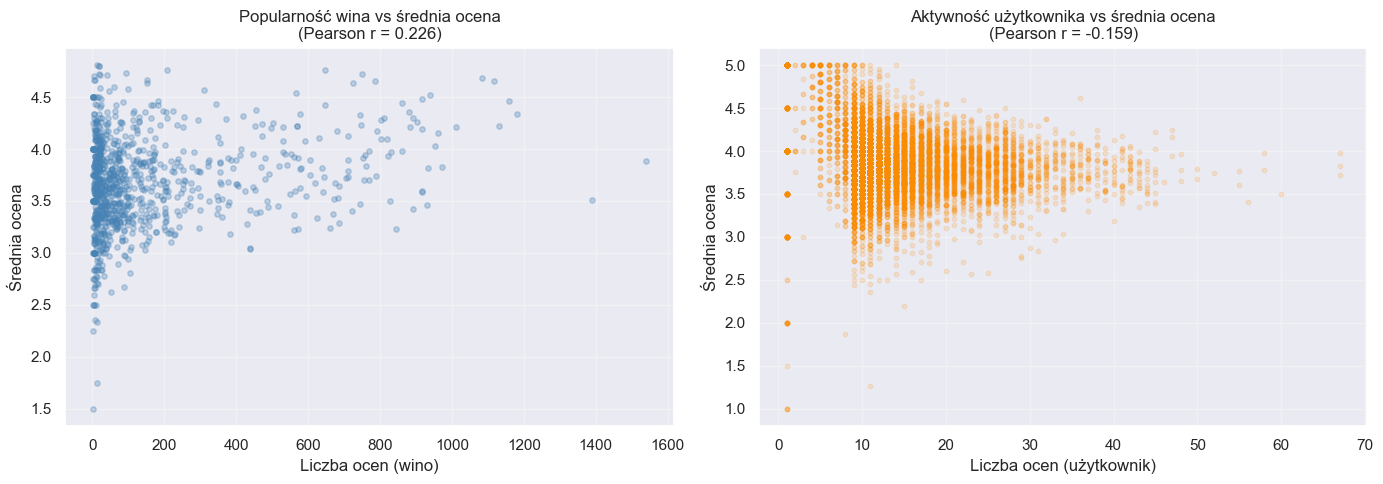

In [9]:
# ═════════════════════════════════════════════════════════════════════════════
# 7. WYKRESY KORELACJI (heatmapa + scatter)
# ═════════════════════════════════════════════════════════════════════════════
 
# 7a. Scatter: popularność wina vs średnia ocena
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].scatter(wine_stats['n_ratings'], wine_stats['avg_rating'],
                alpha=0.3, s=15, color='steelblue')
axes[0].set_xlabel('Liczba ocen (wino)')
axes[0].set_ylabel('Średnia ocena')
axes[0].set_title(f'Popularność wina vs średnia ocena\n(Pearson r = {pearson_wine:.3f})')
axes[0].grid(True, alpha=0.3)
 
# 7b. Scatter: aktywność usera vs średnia ocena
axes[1].scatter(user_stats['n_ratings'], user_stats['avg_rating'],
                alpha=0.15, s=10, color='darkorange')
axes[1].set_xlabel('Liczba ocen (użytkownik)')
axes[1].set_ylabel('Średnia ocena')
axes[1].set_title(f'Aktywność użytkownika vs średnia ocena\n(Pearson r = {pearson_user:.3f})')
axes[1].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('eda_korelacje_scatter.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [10]:
# 7c. Heatmapa korelacji (tabela numeryczna)
corr_data = pd.DataFrame({
    'n_ocen_user':   user_stats['n_ratings'],
    'avg_user':      user_stats['avg_rating'],
})
# Dla wine_stats — osobna (różna liczba wierszy)
print("\n--- Macierz korelacji user_stats ---")
print(corr_data.corr(method='pearson').round(4))


--- Macierz korelacji user_stats ---
             n_ocen_user  avg_user
n_ocen_user       1.0000   -0.1589
avg_user         -0.1589    1.0000



--- Long Tail ---
  Top 20% win pokrywa 71.2% wszystkich ocen
  80% ocen skupia się na 276 winach (27.4% zbioru)


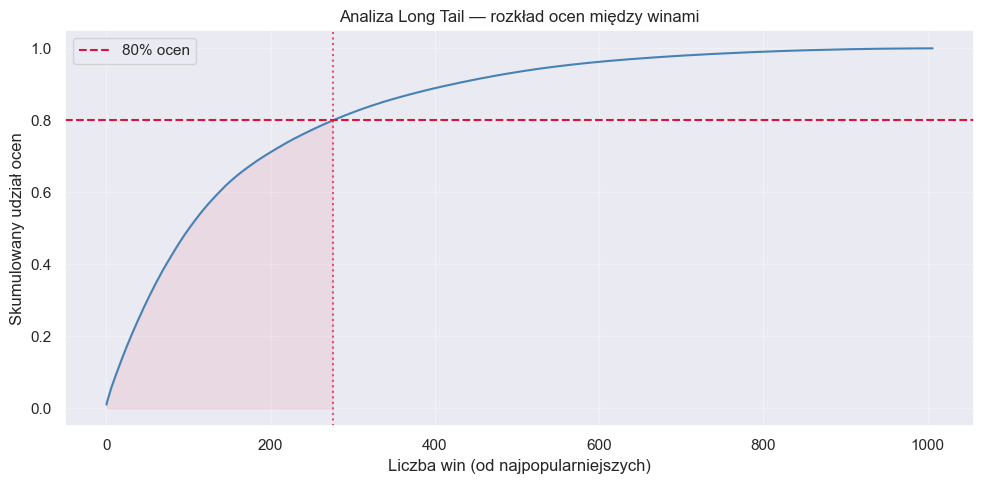

: 

In [ ]:
# 7d. Long Tail — uzupełnienie z % pokrycia
wine_sorted = wine_counts.sort_values(ascending=False)
cumsum_pct = wine_sorted.cumsum() / wine_sorted.sum()
top20_pct  = cumsum_pct.iloc[int(len(cumsum_pct) * 0.2) - 1]
wines_for_80 = (cumsum_pct <= 0.8).sum()
 
print(f"\n--- Long Tail ---")
print(f"  Top 20% win pokrywa {top20_pct*100:.1f}% wszystkich ocen")
print(f"  80% ocen skupia się na {wines_for_80} winach ({wines_for_80/n_wines*100:.1f}% zbioru)")
 
plt.figure(figsize=(10, 5))
plt.plot(np.arange(len(wine_sorted)), cumsum_pct.values, color='steelblue', linewidth=1.5)
plt.axhline(y=0.8, color='crimson', linestyle='--', label='80% ocen')
plt.axvline(x=wines_for_80, color='crimson', linestyle=':', alpha=0.7)
plt.fill_between(np.arange(wines_for_80), cumsum_pct.values[:wines_for_80],
                 alpha=0.08, color='crimson')
plt.xlabel('Liczba win (od najpopularniejszych)')
plt.ylabel('Skumulowany udział ocen')
plt.title('Analiza Long Tail — rozkład ocen między winami')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('eda_long_tail.pdf', bbox_inches='tight', dpi=150)
plt.show()